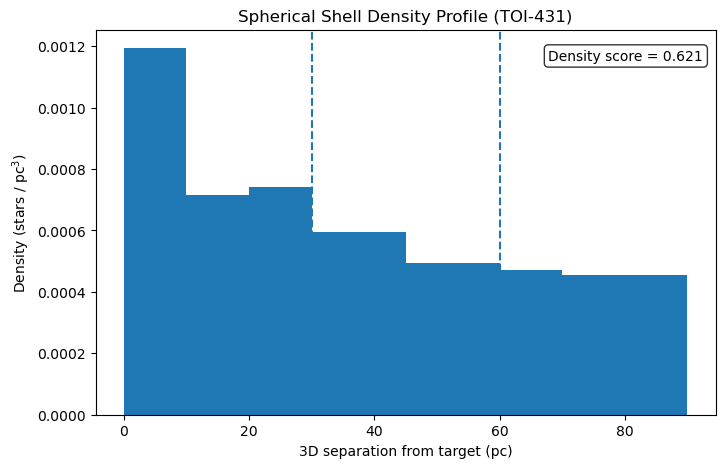

hostname = TOI-431
inner density = 0.0007515650090450614
outer density = 0.00045931558137924186
density_ratio = 1.636271529888551


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def load_friendfinder_csv(csv_path, required_columns=None):
    """
    Load one FriendFinder CSV and return selected columns as NumPy arrays.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file.
    required_columns : list of str, optional
        Columns to extract. Defaults to the main useful ones.

    Returns
    -------
    arrays : dict
        Dictionary mapping column names to NumPy arrays.
    hostname : str
        Filename stem, used as the host name.
    """

    if required_columns is None:
        required_columns = ["3D(pc)", "Sep(deg)", "Voff(km/s)"]

    df = pd.read_csv(csv_path)

    # Clean up accidental spaces in headers
    df.columns = df.columns.str.strip()

    # Check columns exist
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    # Convert selected columns to NumPy arrays
    arrays = {}
    for col in required_columns:
        arrays[col] = pd.to_numeric(df[col], errors="coerce").to_numpy()

    hostname = Path(csv_path).stem

    return arrays, hostname


def spherical_density_test(r_3d, hostname="Target", plot=True):
    """
    Compute a spherical shell density profile and the density ratio:
    density(<30 pc) / density(60-90 pc)

    Parameters
    ----------
    r_3d : array-like
        Array of 3D separations from the target in pc.
    hostname : str
        Name of the target for the plot title.
    plot : bool
        If True, make a histogram-style density plot.

    Returns
    -------
    density_ratio : float
        Ratio of inner density to outer-shell density.
    inner_density : float
        Density for r < 30 pc.
    outer_density : float
        Density for 60 < r <= 90 pc.
    """

    r_3d = np.asarray(r_3d)
    r_3d = r_3d[~np.isnan(r_3d)]   # remove NaNs

    # --- Inner region: r < 30 pc ---
    inner_mask = r_3d < 30
    n_inner = np.sum(inner_mask)
    v_inner = (4/3) * np.pi * (30**3)
    inner_density = n_inner / v_inner

    # --- Outer shell: 60 < r <= 90 pc ---
    outer_mask = (r_3d > 60) & (r_3d <= 90)
    n_outer = np.sum(outer_mask)
    v_outer = (4/3) * np.pi * (90**3 - 60**3)
    outer_density = n_outer / v_outer

    if outer_density == 0:
        density_ratio = np.inf
    else:
        density_ratio = inner_density / outer_density

        return density_ratio, inner_density, outer_density

csv_path = r"ALL_CSVS(Sidequest)\TOI-431.csv"

arrays, hostname = load_friendfinder_csv(csv_path)

r_3d = arrays["3D(pc)"]
sep_deg = arrays["Sep(deg)"]
voff = arrays["Voff(km/s)"]

density_ratio, inner_density, outer_density = spherical_density_test(r_3d, hostname=hostname)

if inner_density + outer_density == 0:
    density_score = np.nan
else:
    density_score = inner_density / (inner_density + outer_density)

bins = np.array([0, 10, 20, 30, 45, 60, 70, 90])
counts, edges = np.histogram(r_3d, bins=bins)

shell_volumes = (4/3) * np.pi * (edges[1:]**3 - edges[:-1]**3)
densities = counts / shell_volumes

plt.figure(figsize=(8, 5))
plt.stairs(densities, edges, fill=True)
plt.xlabel("3D separation from target (pc)")
plt.ylabel("Density (stars / pc$^3$)")
plt.title(f"Spherical Shell Density Profile ({hostname})")
plt.axvline(30, linestyle="--")
plt.axvline(60, linestyle="--")

plt.text(
    0.98, 0.95,
    f"Density score = {density_score:.3f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()

print("hostname =", hostname)
print("inner density =", inner_density)
print("outer density =", outer_density)
print("density_ratio =", density_ratio)